In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

# Probability Review

Recall that the definition of conditional probability is given by:

\begin{align*}
\mathbb{P}(B \mid A) & = \frac{\mathbb{P}(A,B)}{\mathbb{P}(A)} \implies \mathbb{P}(A,B) = \mathbb{P}(A)\mathbb{P}(B \mid A )
\end{align*}

Similarly, applying the defintion to three variables:

\begin{align}
\mathbb{P}(C \mid A, B) &= \frac{\mathbb{P}(A,B,C)}{\mathbb{P}(A,B)} \implies \mathbb{P}(A,B,C) = \mathbb{P}(A,B)\mathbb{P}(C \mid A, B)
\end{align}

Since we know $\mathbb{P}(A,B) = \mathbb{P}(A)\mathbb{P}(B \mid A )$, we can subsituting this into (1), which yields:

\begin{align*}
\mathbb{P}(A,B,C) = \mathbb{P}(A)\mathbb{P}(B \mid A )\mathbb{P}(C \mid A, B)
\end{align*}

This illustrates a general rule, called the chain rule of probability, which states that for any collection of random variables:

\begin{align*}
\mathbb{P}(X_1, X_2, \dots, X_n) &= \prod_{i=1}^n \mathbb{P}(X_i \mid X_1, X_2, \dots, X_{i-1})
\end{align*}


Now, this general formulation can become quite complex since each variable potentially depends on the entire history before it. This is where Markov Chains can offer a significant simplification. 


# Markov Chains

A Markov Chain is a probabilistic model that describes how a system evolves over time through a sequence of states,
\begin{align*}
\{X^{(t)}\} \qquad t = 0,1,2,\dots
\end{align*}
where at each time step, the system occupies exactly one state from a set of states known as the state space $\mathcal{S}$,
\begin{align*}
X^{(t)} \in \mathcal{S} = \{S_1, S_2, \dots, S_N\}.
\end{align*}
The defining feature of the Markov Chain is the Markov Property, which states that the probability of transitioning to the next state depends only on the current state. 

\begin{align*}
\mathbb{P}[X^{(t+1)} = j \mid X^{(t)} = i] \tag{2}
\end{align*}

In other words, (2) represents the probability of moving from state $i$ to state $j$, which can conviently be expressed using transation probabilities $a_{ij}$

\begin{align*}
\mathbb{P}[X^{(t+1)} = j \mid X^{(t)} = i] = a_{ij}^{(t)} \quad \quad \forall i,j \in \mathcal{S}
\end{align*}

These transition probabilities can then be collected into the transition matrix:
\begin{align*}
    A^{(t)}= \left\{a_{ij}^{(t)}\right\}=
    \begin{pmatrix}
        a_{11}^{(t)} & a_{12}^{(t)} & \cdots & a_{1N}^{(t)}\\
        a_{21}^{(t)} & a_{22}^{(t)} & \cdots & a_{2N}^{(t)}\\
        \vdots & \vdots & \ddots & \vdots \\
        a_{N1}^{(t)} & a_{N2}^{(t)} & \cdots & a_{NN}^{(t)}
    \end{pmatrix}
\end{align*}
where $a_{ij}^{(t)}\ge 0$ and each row sums to one:

\begin{align*}
\sum_{j=1}^N a_{ij}^{(t)}=1, \quad \forall i
\end{align*}

Now, over many transitions, a Markov chain eventually settles into a stable pattern of behavior. It spends a predictable proportion of time in each state, regardless of where it started. This long–run behavior is represented by the stationary distribution,

\begin{align*}
\mathbf{\pi} = (\pi_1, \pi_2, \dots, \pi_N)
\end{align*}

Intuitively, each component $\pi_j$, gives the fraction of time the process spends in state $j$ in the long run. Speicifically, 

\begin{align*}
\lim_{t \to \infty}\mathbb{P}[X^{(t+1)} = j] =  \pi_j, \qquad \forall j
\end{align*}

For a Markov chain with transition matrix $A$, the stationary distribution satisfies

\begin{align*}
\pi = \pi A, \quad \sum_{j=1}^N \pi_j = 1
\end{align*}

This system is equivalent to solving the homogeneous matrix equation
\begin{align*}
0 &= \pi A - \pi \implies \mathbf{\pi}(A - I) = 0
\end{align*}
where $I$ is a $N\times N$ identiy matrix, here $N$ denotes the number of states.

As an example, suppose we observe the two state transition matrix:
\begin{align*}
A &= \begin{pmatrix}
0.8 & 0.2 \\ 
0.3 & 0.7
\end{pmatrix}
\end{align*}

So solving for $\pi$ we see:

\begin{align*}
\pi(A - I)=0 \quad \implies \quad (A - I)^T \pi^T = 0
\end{align*}

Thus,

\begin{align*}
(A^T - I)\pi^T
=
\begin{pmatrix}
-0.2 & 0.3\\
0.2 & -0.3
\end{pmatrix}
\begin{pmatrix}
\pi_1\\
\pi_2
\end{pmatrix}
=
\begin{pmatrix}
0\\
0
\end{pmatrix}
\end{align*}

Multiplying the matrix by $10$ eliminates decimals:

\begin{align*}
\begin{pmatrix}
-2 & 3\\
2  & -3
\end{pmatrix}

\begin{pmatrix}
\pi_1\\
\pi_2
\end{pmatrix}
=
\begin{pmatrix}
0\\
0
\end{pmatrix}
\end{align*}

Since this homogeneous system has infinitely many solutions, we impose the normalization condition for probabilities,
\begin{align*}
\pi_1 + \pi_2 = 1
\end{align*}

Therefore, the system to solve is
\begin{align*}
\begin{cases}
-2\pi_1 + 3\pi_2 = 0,\\ 
\pi_1 + \pi_2 = 1
\end{cases}
\end{align*}

We now augment and row reduce:

\begin{align*}
\left[
\begin{array}{cc|c}
-2 & 3 & 0\\
1 & 1 & 1
\end{array}
\right]

\xrightarrow{R_1 \leftrightarrow R_2}
\left[
\begin{array}{cc|c}
1 & 1 & 1\\
-2 & 3 & 0
\end{array}
\right]
\end{align*}

\begin{align*}
\xrightarrow{R_2 \leftarrow R_2 + 2R_1}
\left[
\begin{array}{cc|c}
1 & 1 & 1\\
0 & 5 & 2
\end{array}
\right]

\xrightarrow{R_2 \leftarrow \frac{1}{5}R_2}
\left[
\begin{array}{cc|c}
1 & 1 & 1\\
0 & 1 & \frac{2}{5}
\end{array}
\right]
\end{align*}

\begin{align*}
\xrightarrow{R_1 \leftarrow R_1 - R_2}
\left[
\begin{array}{cc|c}
1 & 0 & \frac{3}{5}\\
0 & 1 & \frac{2}{5}
\end{array}
\right]
\end{align*}

Thus we obtain
\begin{align*}
\pi_1 = \frac{3}{5} = 0.6, \qquad
\pi_2 = \frac{2}{5} = 0.4.
\end{align*}



In [2]:

A = np.array([[0.8, 0.2],
              [0.3, 0.7]])

N = A.shape[0]           # Number of states
I = np.eye(N)            # Identity matrix

#Numpy solves for column vectors, so we need to transpose A (eg Mx = b)
D = A.T - I

# Append constraint sum(pi) = 1
D = np.vstack((D, np.ones(N)))

# Right-hand side vector: zeros + 1 for the constraint
b = np.zeros(N)
b = np.append(b, 1)

# Solve the linear system
pi = np.linalg.lstsq(D, b)[0]

print("Stationary distribution π:")
print(pi)


Stationary distribution π:
[0.6 0.4]


Here, $\pi$ implies that the system spends approximately 60% of its time in state 1 and 40% in state 2.

Now recall,

\begin{align*}
\mathbb{P}(X_1, X_2, \dots, X_n) &= \prod_{i=1}^n \mathbb{P}(X_i \mid X_1, X_2, \dots, X_{i-1})
\end{align*}

This means, 

\begin{align*}
\mathbb{P}(X_1, X_2 \dots, X_n) = \mathbb{P}(X_1)\cdot \mathbb{P}(X_2 \mid X_3) \cdot \mathbb{P}(X_3 \mid X_1, X_2) \cdot ... \cdot \mathbb{P}(X_n \mid X_1,\dots, X_{n-1})
\end{align*}

Notice, if you apply the Markov Property:
\begin{align*}
\mathbb{P}(X_3 \mid X_1, X_2) &\implies \mathbb{P}(X_3 \mid X_2) \\ 
\mathbb{P}(X_4 \mid X_1,X_2, X_3) &\implies \mathbb{P}(X_4 \mid X_3) \\
&\vdots\\
\mathbb{P}(X_n \mid X_1, \dots, X_{n-1}) &\implies \mathbb{P}(X_n \mid X_{n-1})
\end{align*}
In other words, we can generalize 

\begin{align*}
\mathbb{P}(X_i \mid X_1, \dots, X_{i-1}) = \mathbb{P}(X_i \mid X_{i-1}) \quad \forall i\geq 2 \implies \mathbb{P}(X_1) \prod_{i=2}^n \mathbb{P}(X_i \mid X_{i-1})
\end{align*}


# Discrete Markov Process

Consider the three state markov process illustrated in the Figure 1:

<div style="text-align: center;">
<img src="discrete_hmm.png" alt="Three State Markov Chain diagram" width="500"/>
</div>

As we can see the three states are related to each other and themselves through the transition probabilities, represented by the arrows, where again $a_{ij}$ represents the probability of moving from state i to state j, which collectively make up:

\begin{align*}
A = \begin{pmatrix}
a_{11} & a_{12} & a_{13} \\ 
a_{21} & a_{22} & a_{23} \\ 
a_{31} & a_{32} & a_{33}
\end{pmatrix}
\end{align*}

Now, suppose we observe a particular sequence of states

\begin{align*}
O = \{S_3, S_3, S_1, S_2 \} \quad \text{for } t = 1,2,3,4
\end{align*}

To calculate the probability of observing this sequence given our model, we start with the probability of beginning in a specific initial state —  which in this case, is state three — and then multiply by the corresponding conditional probabilities of transitioning to the next state given the current one. Thanks to the Markov Property, these conditional probabilities are simply the product of the transition probabilities


\begin{align*}
\mathbb{P}(O \mid Model) &= \mathbb{P}(S_{1:4} \mid Model) \\
&= \mathbb{P}(S_3, S_3, S_1, S_2 \mid Model) \\
&= \mathbb{P}(S_3) \cdot \mathbb{P}(S_3 \mid S_3) \cdot \mathbb{P}(S_1 \mid S_3) \cdot \mathbb{P}(S_2 \mid S_1) \\
&= \pi_3 \cdot a_{33} \cdot a_{31} \cdot a_{12}
\end{align*}

Where $\pi_j$ is the initial state probability $\mathbf{\pi}= (\pi_1, \pi_2, \pi_3)$.


# Hidden Markov Models

Now, in the real-world, the true underlying states are rarely observable — they’re often hidden from us. Instead, what we do observe are outcomes or signals that are indirectly influenced by those hidden states.

So, let’s introduce an unobserved state variable, denoted by $Z_t$, which represents the true but hidden condition of the system at time $t$. This hidden state evolves over time according to the same Markov property we discussed earlier, meaning that the probability of being in a particular state at time $t+1$ depends only on the state at time $t$. Similarly, moving from any hidden state $i$ to another hidden state $j$, is governed by the transition probabilities, $a_{ij}$.

As an example, consider the Figure 2, which describes a system with two hidden states, $Z_1$ and $Z_2$, and each of these hidden states generates one of three possible observations: $S_1$, $S_2$, or $S_3$.


<div style="text-align: center;">
<img src="hidden_markov_model.png" alt="Two State HMM diagram" width="500"/>
</div>

Now whats new here, is that the hidden states and the observable outcomes are related through the dashed arrows which represent the emission probabilities, in other words, these probabilities define the probability of observing a specific outcome $S_k$, given that the system is currently in hidden state $𝑗$ at time $t$.

\begin{align*}
b_j(k) = \mathbb{P}(O_t = S_k \mid Z_t = j)
\end{align*}

 Collectively, these emission probabilities form the emission matrix $B = \{ b_{jk} \}$. In the case of ontinuous observations, we can instead model the observation $O_t$ as a random variable in $\mathbb{R}^M$. If we assume that $O_t$ conditioned on state $j$ follows a Gaussian distribution then,
\begin{align*}
O_t \sim \mathcal{N}(\mu_j, \sigma_j^2)
\end{align*}

then the emission probability is expressed as:
\begin{align*}
b_j(o) = \mathcal{N}(o \mid \mu_j, \sigma_j^2)
= \frac{1}{\sqrt{2\pi\sigma_j^2}} 
\exp\!\left(-\frac{(o - \mu_j)^2}{2\sigma_j^2}\right),
\qquad j = 1,2,\dots,N
\end{align*}

In other words, each hidden state is associated with its own emission distribution, characterized by a distinct mean and variance.


In [ ]:
from scipy.stats import multivariate_normal

class GaussinEmission:
    '''Class for Gaussian emissions in an HMM
    
    Attributes:
        n_states: number of hidden states (N)
        n_features: number of features in the observation (M)
        means: array of shape (N, M) containing mean vectors for each state
        covars: array of shape (N, M, M) containing covariance matrices for each state
    returns:
        emission_prob(state, observation): returns the probability density of the observation given the state    
    '''

    def __init__(self, n_states=2, n_features=1):
        self.n_states = n_states
        self.n_features = n_features
        
        # Store Gaussian parameters for each state
        self.means = np.random.randn(n_states, n_features)
        self.covars = np.array([np.eye(n_features) for _ in range(n_states)])
    
    def emission_prob(self, state, observation):
        """
        Compute b_j(o) = N(o | mu_j, cov_j)
        
        Args:
            state: integer j in {0, 1, ..., N-1}
            observation: vector o in R^M
        
a        Returns:
            Probability density p(o | state j)
        """
        return multivariate_normal.pdf(
            observation, 
            mean=self.means[state], 
            cov=self.covars[state]
        )
    
    def compute_emission_probs(self, observations):
        """
        Compute B matrix for all observations
        
        Args:
            observations: array of shape (T, M) where T = time steps, M = features
        
        Returns:
            B: array of shape (T, N) where B[t, j] = b_j(O_t)
        """
        T = len(observations)
        B = np.zeros((T, self.n_states))
        
        for t in range(T):
            for j in range(self.n_states):
                B[t, j] = self.emission_prob(j, observations[t])
        
        return B

# Example for 2 states, 1D observations
g = GaussinEmission(n_states=2, n_features=1)

# Set parameters manually 
g.means = np.array([[0.0], [5.0]])      # mu_1 = 0, mu_2 = 5
g.covars = np.array([[[1.0]], [[2.0]]]) # sigma2_1 = 1, sigma2_2 = 2
# Sample observations
O = np.array([[0.5], [5.2], [0.1], [4.8]]).reshape(-1, 1)

# Compute emission probabilities
B = g.compute_emission_probs(O)
print("B shape:", B.shape)  # (4, 2) - 4 time steps, 2 states
print("B:\n", B)

B shape: (4, 2)
B:
 [[3.52065327e-01 1.78557976e-03]
 [5.36103534e-07 2.79287902e-01]
 [3.96952547e-01 6.97497155e-04]
 [3.96129909e-06 2.79287902e-01]]


# Likelihood

So ultimately, what we’re trying to find is the joint probability of the entire sequence of hidden states and the corresponding sequence of observations:

\begin{align*}
L(\lambda) 
&= \mathbb{P}(O_{1:T}, Z_{1:T} \mid \lambda) \\
&= \mathbb{P}(Z_1) \, \mathbb{P}(O_1 \mid Z_1)
   \prod_{t=2}^T \mathbb{P}(Z_t \mid Z_{t-1})
   \prod_{t=1}^T \mathbb{P}(O_t \mid Z_t)
\end{align*}


 Where the observation sequence is 

  \begin{align*}
    O = \{S_1, S_2, \dots, S_T\}
  \end{align*}

  * Note:

    (1) Transition probabilities, using one–hot indicators $z_{t,i} \in \{0,1\}$,
    \begin{align*}
      \mathbb{P}(Z_t \mid Z_{t-1})
      = \prod_{i=1}^N \prod_{j=1}^N a_{ij}^{\,z_{t-1,i} z_{t,j}}.
    \end{align*}
    (2) Emission probability for state $j$,
    \begin{align*}
      b_j(o) = \mathbb{P}(O_t = o \mid Z_t = j).
    \end{align*}
    (3) Emission distribution at time $t$, written with one–hot indicators
         $z_{t,j}$ for the hidden state and $o_{t,k}$ for the observed symbol,
    \begin{align*}
      \mathbb{P}(O_t \mid Z_t)
      = \prod_{j=1}^N \prod_{k=1}^M b_{jk}^{\,z_{t,j} o_{t,k}}.
    \end{align*}
    (4) Initial state distribution, again using indicators $z_{1,i}$,
    \begin{align*}
      \mathbb{P}(Z_1 \mid \pi)
      = \prod_{i=1}^N \pi_i^{\,z_{1,i}}.
    \end{align*}

Thus, the system can be defined by the parameter set:

  \begin{align*}
    \lambda = (A, B, \pi)
  \end{align*}

  where $A = \{a_{ij}\}$ is the transition matrix, $B = \{b_{jk}\}$ the emission matrix,
  and $\pi = \{\pi_i\}$ the initial distribution.


Substituting these pieces into the factorization of $\mathbb{P}(O_{1:T}, Z_{1:T} \mid \lambda)$ gives:

  \begin{align*}
    L(\lambda)
    = \pi_{Z_1}
      \prod_{t=2}^T a_{Z_{t-1}, Z_t}
      \prod_{t=1}^T b_{Z_t}(O_t)
  \end{align*}

  i.e., the joint likelihood as a product of initial, transition, and emission terms along the specific hidden path $Z_{1:T}$.



# Baum-Welch Algorithm / Forward-Backward Algorithm

So how do we then find the optimal parameters $\lambda$ that best explains our observed data? To answer this, we can use the Baum–Welch algorithm or sometimes referred to as the Forward-Backward algorithm, which is really just special case of the Expectation Maximization method, which helps us answer three key questions:

1): given a sequence of observations and our model, how do we compute the likelihood of those observations? 

2):  how do we infer the most likely sequence of hidden states that produced them? 

3): how can we adjust the model parameters themselves so that the model becomes more likely to generate the data we observed? 


## Forward-Algorithm

So starting with the forward part of the Baum-Welch algorithm, we first start by defining the forward variable, $\alpha_t(j)$, which represents the joint probability of observing our sequence up to time $t$ and being in hidden state $j$ at that specific moment.

\begin{align*}
\alpha_t(j) = \mathbb{P}(O_{1:t}, Z_t =j \mid \lambda)
\end{align*}

Since this value is computed for every time step $t = 1,\dots,T$ and every hidden state 
$j = 1,\dots,N$, the full set of forward probabilities forms a matrix 
$\alpha \in \mathbb{R}^{T \times N}$, where $ \alpha_t(j) \in [0,1] $.

Now, thanks to the Markov Property where the current hidden state depends only on the previous state, these forward probabilities can be computed recursively as follows:

1): Initalize at time $t=1$: The probability of starting in state $j$ and emitting the first observation $O_1$ is:

\begin{align*}
\alpha_1(j) = \pi_j b_j(O_1)
\end{align*}

where $ \pi_j $ is the initial state probability and $ b_j(\cdot) $ is the emission probability in state $j$.

2): Recursion $t \geq 2$:  
    To compute the probability of being in state $j$ at time $t$, we sum all paths coming from every previous state $i$, weighted by the transition probabilities $a_{ij}$, and multiply by the emission probability at $t$:

\begin{align*}
\alpha_t(j) 
= \left( \sum_{i=1}^{N} \alpha_{t-1}(i)\, a_{ij} \right) b_j(O_t)
\end{align*}


To help visualize (2), consider Figure 3, to find the probability of landing in state $j$ at time $t+1$, we must consider every possible state $i$ we could have come from. 

<div style="text-align: center;">
<img src="forward_algo.png" alt="Forward Algorithm" width="500"/>
</div>

Finally, once we have computed the forward probabilities up to the last time step, the likelihood of the entire observation sequence under the model parameters $\lambda$ is obtained by summing the forward values at time $T$:
\begin{align*}
\mathcal{L}(\lambda) = \mathbb{P}(O_{1:T} \mid \lambda)
= \sum_{j=1}^{N} \alpha_T(j)
\end{align*}
In other words, each hidden state could be the final state at time $T$, so we add the probabilities of all possible ending states to obtain the total likelihood of the observed sequence.


In [ ]:
def forward_algorithm(A, B, pi,eps=1e-10):
    '''
    Compute the forward probabilities alpha and the likelihood L of the observation sequence. P(O | lambda), L = sum_j alpha_T(j)

    args:
        A: Transition matrix of shape (N, N)
        B: Emission probability matrix of shape (T, N)
        pi: Initial state distribution of shape (N,)
    returns:
        alpha: Forward probabilities of shape (T, N)
        L: Likelihood of the observation sequence
    '''

    T, N = B.shape
    
    # Initialize alpha matrix
    alpha = np.zeros((T, N))   
    # Initialization step 
    alpha[0, :] = pi * B[0, :]
    alpha[0, :] /= alpha[0, :].sum()
    
    # Recursion step 
    for t in range(1, T):
        for j in range(N):
            alpha[t, j] = np.sum(alpha[t-1, :] * A[:, j]) * B[t, j]
        s = np.sum(alpha[t, :])
        if np.isnan(s) or s == 0:
            s = eps
        alpha[t, :] /= s
    
    # Log-likelihood
    L = np.sum(np.log(alpha[-1, :] + eps))
    
    return alpha, L
    

## Backward Algorithm

Similarly, the Backward Algorithm computes what we call the backward probability, denoted by the variable $\beta_t(i)$. This represents the probability of observing all future observations—from time $t+1$ through the final time step—given that we are currently in hidden state $i$ at time $t$.

Unlike the forward algorithm, which begins at $t = 1$ and moves forward, the backward algorithm works in the opposite direction, where we start at the final time step, initializing $\beta = 1$ for every state $i$. 

From there, we move backward in time. So for every time step $t$, we compute the value for $\beta$ by summing across all possible future states $j$. Specifically, we multiply three values: the probability of transitioning to state $j$, the probability of emitting the observation at time $t+1$, and the backward probability we just computed for that next step.


\begin{align*}
\beta_t(i) = \mathbb{P}(O_{t+1:T} \mid Z_t = i)
&= \sum_{j} \mathbb{P}(Z_{t+1} = j, O_{t}, O_{t+1:T} \mid Z_t = i)\\
&= \sum_{j} \mathbb{P}(Z_{t+1} = j \mid Z_t = i)\,
   \mathbb{P}(O_{t+1} \mid Z_{t+1} = j)\,
   \mathbb{P}(O_{t+2:T} \mid Z_{t+1} = j)\\
&= \sum_{j} a_{ij}\, b_j(O_{t+1})\, \beta_{t+1}(j),
\qquad t = T-1, \ldots, 1.
\end{align*}


<div style="text-align: center;">
<img src="backward_algo.png" alt="Backward Algorithm" width="500"/>
</div>

In [ ]:
def backward_algorithm(A, B):
    '''
    backward algorithm to compute beta matrix 

    args:
        A: N x N state transition probability matrix
        B: T x N observation likelihood matrix
    returns:
        beta: T x N matrix of backward probabilities
    '''
    T, N = B.shape
    
    # Initialize beta matrix
    beta = np.zeros((T, N))
    
    # Initialization step
    beta[T-1, :] = 1 #* c[T-1]
    
    
    # Recursion step
    for t in range(T-2, -1, -1):
        for i in range(N):
            beta[t, i] = np.sum(A[i, :] * B[t+1, :] * beta[t+1, :])
        s = np.sum(beta[t, :])
        if np.isnan(s) or s == 0:
            s = eps
        beta[t, :] /= s

    return beta

## State and Transistion Posteriors

And so the reason why we need both the forward and backward recursions is because no single pass through time contains all the information needed to compute the posterior distribution of the hidden states.

In an Hidden Markov Model, each hidden state is influenced by not only the observations before time $t$ but also observations after time $t$. 

So combining both pieces of information gives us the smoothed posterior, denoted here by the variable $\gamma$. Intuitively, what this quantity represents is the probability that the system was in hidden state j at time t, given all of our observations:

\begin{align*}
\gamma_t(i) = \mathbb{P}(Z_t = i \mid O_t, \lambda) = \frac{\mathbb{P}(O, Z_t = i \mid \lambda)}{\mathbb{P}(O \mid \lambda)}= \frac{\alpha_t(i) \odot \beta_t(i)}{\sum_{j=1}^N \alpha_t(j) \odot\beta_t(j)}
\end{align*}


In [6]:
def compute_gamma(alpha, beta, eps=1e-10):
    ''' 
    compute gamma_t(i) = P(Z_t = i | O, lambda) 

    args:
        alpha: T x N matrix of forward probabilities
        beta: T x N matrix of backward probabilities
    returns:
        gamma: T x N matrix of state probabilities at each time step
    '''
    T, N = alpha.shape
    gamma = np.zeros((T, N))
    
    for t in range(T):
        denominator = np.sum(alpha[t, :] * beta[t, :]) + eps
        for i in range(N):
            gamma[t, i] = (alpha[t, i] * beta[t, i]) / denominator
    
    return gamma

Now we currently have the terms:  $\alpha$, $\beta$ and $\gamma$, which tell us the probability of being in a state $j$. But we also need to know how often the model moves from state $i$ to state $j$. Therefore, we need to define a new term, which we can denote by the variable $\xi$  which specifically tracks the system being in state $i$ at time $t$ and transitions to state $j$ at time $t + 1$:

\begin{align*}
\xi_t(i, j) = \mathbb{P}(Z_t = i, Z_{t+1} = j \mid O_{1:T}, \lambda) = \frac{\alpha_t(i) \cdot a_{ij} \cdot b_j(O_{t+1}) \cdot \beta_{t+1}(j)}{\sum_{i=1}^{N} \sum_{j=1}^{N} \alpha_t(i) \cdot a_{ij} \cdot b_j(O_{t+1}) \cdot \beta_{t+1}(j)}
\end{align*}
 

In [7]:
def compute_xi(alpha, beta, A, B, eps=1e-10):
    '''Compute xi_t(i, j) = P(q_t = i, q_{t+1} = j | O, lambda)
    args:
        alpha: T x N matrix of forward probabilities
        beta: T x N matrix of backward probabilities
        A: N x N state transition probability matrix
        B: T x N observation likelihood matrix
    returns:
        xi: (T-1) x N x N tensor where xi[t, i, j] = P(Z_t = i, Z_{t+1} = j | O, lambda)
    '''
    T, N = alpha.shape
    xi = np.zeros((T-1, N, N))
    
    for t in range(T-1):
        denominator = np.sum(alpha[t, :] * np.sum(A * B[t+1, :] * beta[t+1, :], axis=1)) + eps
        for i in range(N):
            for j in range(N):
                xi[t, i, j] = (alpha[t, i] * A[i, j] * B[t+1, j] * beta[t+1, j]) / denominator
    
    return xi

<div style="text-align: center;">
<img src="state_transistion.png" alt="xi" width="500"/>
</div>

In [8]:
def forward_backward(A, B, pi):
    alpha, L = forward_algorithm(A, B, pi)
    beta = backward_algorithm(A, B)
    gamma = compute_gamma(alpha, beta)
    xi = compute_xi(alpha, beta, A, B)
    
    return gamma, xi

# Expectation: E-Step

In the E-step, we compute the expected value of the complete-data log-likelihood,
\begin{align*}
\mathbb{E}\!\left[\log \mathbb{P}(O_{1:T}, Z_{1:T} \mid \lambda)\right]
\end{align*}
where the expectation is taken with respect to the posterior distribution of the hidden states given the observations and the current model parameters $ \lambda = (\pi, A, B) $. Since the sequence of hidden states $Z_{1:T}$ is unknown, we express the log-likelihood in a form that separates initial state probabilities, state transitions, and emission probabilities:

\begin{align*}
\mathbb{E}\!\left[\log \mathbb{P}(O_{1:T}, Z_{1:T} \mid \lambda)\right]
= \mathbb{E}[\log \pi_{Z_1}]
+ \mathbb{E}\!\left[\sum_{t=2}^T \log a_{Z_{t-1}, Z_t}\right]
+ \mathbb{E}\!\left[\sum_{t=1}^T \log b_{Z_t}(O_t)\right]
\end{align*}

1. Initial State Probability Term:

The first term involves the probability of the hidden state at the initial time step. Because we do not know which state the model actually began in, we weight this term by the posterior probability $ \gamma_1(i) \equiv \mathbb{P}(Z_1 = i \mid O_{1:T}) $:

\begin{align*}
\mathbb{E}[\log \pi_{Z_1}]
= \sum_i \mathbb{P}(Z_1 = i \mid O_{1:T}) \log \pi_i
= \sum_i \gamma_1(i) \log \pi_i
\end{align*}

Here, $ \gamma_1(i) $ represents the expected responsibility of state $i$ for generating the first observation.

2. Transition Probability Term:

The next contribution comes from state transitions. Since we do not directly observe transitions, we again take expectations, this time over the joint posterior probability of transitioning from state $i$ to $j$ at time $t$:
\begin{align*}
\mathbb{E}\!\left[\sum_{t=2}^T \log a_{Z_{t-1}, Z_t}\right]
= \sum_{t=2}^T \sum_{i,j} \mathbb{P}(Z_{t-1} = i, Z_t = j \mid O_{1:T}) \log a_{ij}
= \sum_{t=2}^T \sum_{i,j} \xi_t(i,j) \log a_{ij}
\end{align*}

The quantity $ \xi_t(i,j) $ gives the expected number of transitions from state $i$ to $j$ at time $t$. Thus, transitions are weighted according to how likely they actually occurred given the observed data.

3. Emission Probability Term:

Finally, we account for the probability of emitting observation $O_t$ while in state $j$. Once again, we weight by the posterior probability $ \gamma_t(j) = \mathbb{P}(Z_t = j \mid O_{1:T}) $:

\begin{align*}
\mathbb{E}\!\left[\sum_{t=1}^T \log b_{Z_t}(O_t)\right]
= \sum_{t=1}^T \sum_j \gamma_t(j) \log b_j(O_t)
\end{align*}

Intuitively, each state contributes to the likelihood of the observations according to how responsible it is (on average) for generating them.


Combining all three components, we obtain the expected complete-data log-likelihood:

\begin{align*}
\log \mathbb{P}(O_{1:T}, Z_{1:T} \mid \lambda)
= \sum_i \gamma_1(i)\log \pi_i
+ \sum_{t=2}^T \sum_{i,j} \xi_t(i,j) \log a_{ij}
+ \sum_{t=1}^T \sum_j \gamma_t(j) \log b_j(O_t)
\end{align*}

Thus, the Q-function evaluated at the current parameters $ \lambda^{(t)} $ is

\begin{align*}
Q(\lambda, \lambda^{(t)}) 
= \mathbb{E}_{Z \mid O, \lambda^{(t)}}\!\left[\log \mathbb{P}(O_{1:T}, Z_{1:T} \mid \lambda)\right]
= \sum_i \gamma_1(i)\log \pi_i
+ \sum_{t=2}^T \sum_{i,j} \xi_t(i,j) \log a_{ij}
+ \sum_{t=1}^T \sum_j \gamma_t(j) \log b_j(O_t)
\end{align*}

This expression forms the basis for the M-step, where we maximize $Q(\lambda, \lambda^{(t)})$ to update the parameters $ (\pi, A, B) $.

# Optimization: M-Step

In the E-step, we showed that the expected complete-data log-likelihood (the
Q-function) for a Hidden Markov Model with parameters  $\lambda = (\pi, A, B)$ can be written as

\begin{align*}
Q(\lambda, \lambda^{(t)}) 
= \sum_i \gamma_1(i)\log \pi_i
+ \sum_{t=2}^T \sum_{i,j} \xi_t(i,j) \log a_{ij}
+ \sum_{t=1}^T \sum_j \gamma_t(j) \log b_j(O_t),
\end{align*}

where 
\begin{align*}
\gamma_t(j) &= \mathbb{P}(Z_t = j \mid O_{1:T}, \lambda^{(t)}) \\
\xi_t(i,j) &= \mathbb{P}(Z_{t-1} = i, Z_t = j \mid O_{1:T}, \lambda^{(t)})
\end{align*}

are computed by the Forward--Backward algorithm.

In the M-step, we want to maximize $Q(\lambda, \lambda^{(t)})$ with respect to the parameters $\lambda = (\pi, A, B)$, subject to the usual probability constraints:


\begin{align*}
\sum_j a_{ij} &= 1, &&\forall i \quad &\text{(rows of the transition matrix)} \\
\sum_i \pi_i &= 1,   &&             &\text{(initial state distribution)} \\
\sum_j b_j(S_k) &= 1, &&\forall j \quad &\text{(emission probabilities per state).}
\end{align*}


To maximize $Q$ under these constraints, we introduce Lagrange multipliers
$\eta$ (for $\sum_i \pi_i =1$), $\alpha_i$ (for each row of $A$), and
$\beta_j$ (for each emission distribution in $B$). The Lagrangian is

\begin{align*}
\mathcal{L}
&= Q(\lambda, \lambda^{(t)}) 
   + \eta\Big(\sum_i \pi_i - 1\Big)
   + \sum_i \alpha_i\Big(\sum_j a_{ij} - 1\Big)
   + \sum_j \beta_j\Big(\sum_k b_j(S_k) - 1\Big).
\end{align*}

We then differentiate $\mathcal{L}$ with respect to each parameter and set
the derivatives to zero to obtain the optimal updates.

1): Update for the Initial Distribution $\pi$:

The part of $\mathcal{L}$ involving $\pi_i$ is
\begin{align*}
\sum_i \gamma_1(i) \log \pi_i + \eta \Big(\sum_i \pi_i - 1\Big).
\end{align*}
Differentiating with respect to $\pi_i$ and setting to zero:
\begin{align*}
\frac{\partial \mathcal{L}}{\partial \pi_i}
= \frac{\gamma_1(i)}{\pi_i} + \eta = 0
\quad\Rightarrow\quad
\pi_i = -\frac{\gamma_1(i)}{\eta}.
\end{align*}
Enforcing $\sum_i \pi_i = 1$ gives $\eta = -1$, so
\begin{align*}
\pi_i^{(t+1)} = \gamma_1(i).
\end{align*}
in other words, the updated initial probability for state $i$ is simply
the posterior probability that the chain starts in state $i$.

2): Update for the Transition Probabilities $a_{ij}$:

The terms involving $a_{ij}$ are

\begin{align*}
\sum_{t=2}^T \sum_{i,j} \xi_t(i,j) \log a_{ij}
+ \sum_i \alpha_i\Big(\sum_j a_{ij} - 1\Big)
\end{align*}

Differentiating with respect to $a_{ij}$:
\begin{align*}
\frac{\partial \mathcal{L}}{\partial a_{ij}}
= \frac{\sum_{t=2}^T \xi_t(i,j)}{a_{ij}} + \alpha_i = 0
\quad\Rightarrow\quad
a_{ij} = -\frac{\sum_{t=2}^T \xi_t(i,j)}{\alpha_i}.
\end{align*}
Using the constraint $\sum_j a_{ij} = 1$, we obtain
\begin{align*}
\alpha_i = -\sum_{t=2}^T \sum_{j} \xi_t(i,j),
\end{align*}
and hence
\begin{align*}
a_{ij}^{(t+1)}
= \frac{\sum_{t=2}^T \xi_t(i,j)}
       {\sum_{t=2}^T \sum_{j'} \xi_t(i,j')}.
\end{align*}

note: $a_{ij}^{(t+1)}$ is the expected number of transitions
from state $i$ to state $j$, divided by the expected total number of
transitions out of state $i$.

3): Update for Discrete Emission Probabilities $b_j(k)$:

Assume discrete observations taking values in $\{S_1,\dots,S_M\}$. Now let the indicator function $\mathbf{1}\{O_t = S_k\}$. The relevant
terms are

\begin{align*}
\sum_{t=1}^T \sum_j \gamma_t(j) \log b_j(O_t)
+ \sum_j \beta_j\Big(\sum_k b_j(S_k) - 1\Big).
\end{align*}

Differentiating with respect to $b_j(S_k)$ gives

\begin{align*}
\frac{\partial \mathcal{L}}{\partial b_j(S_k)}
= \frac{\sum_{t=1}^T \gamma_t(j)\, \mathbf{1}\{O_t = S_k\}}{b_j(S_k)} + \beta_j = 0
\quad\Rightarrow\quad
b_j(S_k) = -\frac{\sum_{t=1}^T \gamma_t(j)\, \mathbf{1}\{O_t = S_k\}}{\beta_j}.
\end{align*}

Enforcing $\sum_k b_j(S_k) = 1$ yields
\begin{align*}
b_j^{(t+1)}(S_k)
= \frac{\sum_{t=1}^T \gamma_t(j)\, \mathbf{1}\{O_t = S_k\}}
       {\sum_{t=1}^T \gamma_t(j)}.
\end{align*}

note:  the updated emission probability for symbol $S_k$ in
state $j$ is the expected number of times state $j$ emits $S_k$, divided
by the expected total number of times state $j$ is visited.

If instead the emissions in state $j$ are modeled as Gaussian

\begin{align*}
O_t \mid (Z_t = j) \sim \mathcal{N}(\mu_j, \sigma_j^2),
\end{align*}

then the emission parameters $\mu_j$ and $\sigma_j^2$ are updated by
maximizing

\begin{align*}
\sum_{t=1}^T \gamma_t(j) \log \mathcal{N}(O_t \mid \mu_j, \sigma_j^2).
\end{align*}

Differentiation with respect to $\mu_j$ and $\sigma_j^2$ yields the
weighted sample mean and variance:

\begin{align*}
\mu_j^{(t+1)} 
&= \frac{\sum_{t=1}^T \gamma_t(j) O_t}
         {\sum_{t=1}^T \gamma_t(j)}, \\
(\sigma_j^2)^{(t+1)} 
&= \frac{\sum_{t=1}^T \gamma_t(j) \big(O_t - \mu_j^{(t+1)}\big)^2}
         {\sum_{t=1}^T \gamma_t(j)}
\end{align*}

where for each state $j$, the updated mean and variance are
just the empirical mean and variance of the observations, but computed with
weights $\gamma_t(j)$ that represent the posterior probability of being in
state $j$ at time $t$.


In summary, the M-step updates for an HMM can be written as:
\begin{align*}
\pi_i^{(t+1)} 
&= \gamma_1(i), \\
a_{ij}^{(t+1)} 
&= \frac{\sum_{t=2}^T \xi_t(i,j)}
         {\sum_{t=2}^T \sum_{j'} \xi_t(i,j')}, \\
b_j^{(t+1)}(S_k)
&= \frac{\sum_{t=1}^T \gamma_t(j)\, \mathbf{1}\{O_t = S_k\}}
         {\sum_{t=1}^T \gamma_t(j)}
  \quad\text{(discrete emissions)}, \\
\mu_j^{(t+1)} 
&= \frac{\sum_{t=1}^T \gamma_t(j) O_t}
         {\sum_{t=1}^T \gamma_t(j)}, \\
         (\sigma_j^2)^{(t+1)} 
&= \frac{\sum_{t=1}^T \gamma_t(j) \big(O_t - \mu_j^{(t+1)}\big)^2}
         {\sum_{t=1}^T \gamma_t(j)}   \quad (\text{Gaussian emissions})
\end{align*}



In [9]:
def M_step(gamma, xi, O):
    '''Update parameters A, means, and covariances based on gamma and xi
    
    Args:
        gamma: array of shape (T, N) where gamma[t, j] = P(state j at time t | O, A, B)
        xi: array of shape (T-1, N, N) where xi[t, i, j] = P(state i at time t and state j at time t+1 | O, A, B)
        O: array of shape (T, M) representing the observed data

    Returns: Updated parameters: A , means, and covariances
    '''
    T, N = gamma.shape
    M = O.shape[1]
    
    # Update transition probabilities A
    A_new = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            numerator = np.sum(xi[:, i, j])
            denominator = np.sum(gamma[:-1, i])
            A_new[i, j] = numerator / denominator if denominator > 0 else 0
    
    # Update emission parameters (Gaussian case)
    means_new = np.zeros((N, M))
    covars_new = np.zeros((N, M, M))
    
    for j in range(N):
        gamma_j = gamma[:, j].reshape(-1, 1)  # (T, 1)
        sum_gamma_j = np.sum(gamma_j)
        
        if sum_gamma_j > 0:
            means_new[j] = np.sum(gamma_j * O, axis=0) / sum_gamma_j
            
            diff = O - means_new[j]
            covars_new[j] = (gamma_j * diff).T @ diff / sum_gamma_j
        else:
            means_new[j] = np.zeros(M)
            covars_new[j] = np.eye(M)
    
    return A_new, means_new, covars_new

## Initalizing parameters

We have not yet discussed how to initialize the parameters $A$, $B$, and $\pi$. In principle, these quantities may be randomly generated as long as they satisfy the appropriate normalization constraints. However, to improve both convergence speed and the quality of the final solution, it is common to use a \textbf{Gaussian Mixture Model (GMM)} to initialize the emission distribution parameters. A GMM provides a data–driven estimate of cluster means and covariances, which can then serve as informed starting values for each hidden state in the HMM.

Mathematically, a GMM assumes that each observation $x_t$ is generated from one of $K$ latent Gaussian components, each with its own mean and covariance. The likelihood of a single observation is given by:
\begin{align*}
p(x_t) = \sum_{k=1}^K w_k \, \mathcal{N}(x_t \mid \mu_k, \Sigma_k),
\end{align*}
where:
\begin{align*}
    &(1): w_k \text{ are the mixture weights, satisfying } w_k \ge 0 \text{ and } \sum_{k=1}^K w_k = 1,\\
    &(2): \mu_k \text{ and } \Sigma_k \text{ denote the mean and covariance matrix of the k}-th \text{ Gaussian component},\\
    &(3): \mathcal{N}(x \mid \mu_k, \Sigma_k) \text{ represents the multivariate Gaussian density.}
\end{align*}
The parameters $\{w_k, \mu_k, \Sigma_k\}$ are typically estimated using the Expectation--Maximization (EM) algorithm. Once fitted, the Gaussian components may be interpreted as plausible ``hidden states,'' providing a principled initialization for HMMs with Gaussian emissions.


In [10]:
from sklearn.mixture import GaussianMixture

def init_hmm_gmm(O, n_states):
    """
    Initialize HMM parameters using sklearn GaussianMixture.

    Args:
        O: array (T x M) observations
        n_states: number of hidden states

    Returns:
        pi_init  : (N,) initial distribution
        A_init   : (N,N) transition matrix
        mu_init  : (N,M) GMM means
        sigma_init : (N,M,M) GMM covariances
    """
    gmm = GaussianMixture(
        n_components=n_states,
        covariance_type='full',
        random_state=42
    ).fit(O)

    # Means and covariance = Gaussian parameters
    mu_init = gmm.means_
    sigma_init = gmm.covariances_

    # Most likely hidden state per observation
    labels = gmm.predict(O)

    # Initialize pi = frequency of first state in the first observation
    pi_init = np.bincount(labels[:min(10, len(labels))], minlength=n_states)
    pi_init = pi_init / pi_init.sum()

    # Initialize transition matrix from GMM assignments
    A_init = np.zeros((n_states, n_states))
    for t in range(len(labels) - 1):
        A_init[labels[t], labels[t+1]] += 1

    # Normalize rows to sum to 1
    A_init = np.clip(A_init, 1e-6, None)
    A_init = A_init / A_init.sum(axis=1, keepdims=True)

    return pi_init, A_init, mu_init, sigma_init


In [ ]:
def baum_welch(O,n_states,n_iter=100,tol=1e-4,verbose=False):
    """
    Baum-Welch algorithm (EM for HMM with Gaussian emissions).

    Args:
        O: Observations, shape (T, M)
        n_states: Number of hidden states N
        n_iter: Maximum number of EM iterations
        tol: Convergence tolerance on parameter change 
        verbose: If True, prints simple progress info

    Returns:
        A:       Learned transition matrix, shape (N, N)
        pi:      Learned initial state distribution, shape (N,)
        means:   Learned Gaussian means, shape (N, M)
        covars:  Learned Gaussian covariances, shape (N, M, M)
        logliks: List of log-likelihoods per iteration
    """
    T, M = O.shape

    # ---------- Initialization ----------
    pi, A, means, covars = init_hmm_gmm(O, n_states)

    # Emission model: use your GaussianEmission class
    g = GaussinEmission(n_states=n_states, n_features=M)
    g.means = means
    g.covars = covars


    logliks = []

    for it in range(n_iter):
        # ---------- E-step ----------
        # Compute emission probabilities B[t, j] = p(O_t | state j)
        B = g.compute_emission_probs(O)   

        # Forward-backward to get gamma and xi
        gamma, xi = forward_backward(A, B, pi) 

        # Approx log-likelihood from forward probabilities
        _, loglik = forward_algorithm(A, B, pi)
        logliks.append(loglik)

        # ---------- M-step ----------
        # Update transition matrix A and Gaussian parameters
        A_new, means_new, covars_new = M_step(gamma, xi, O)
        # Update initial distribution
        pi_new = gamma[0, :]
        pi_new = pi_new / pi_new.sum()  

        # ---------- Check convergence ----------
        # Stack parameters into one vector for a simple max-change check
        theta_old = np.concatenate([
            A.ravel(), pi.ravel(), g.means.ravel(), g.covars.ravel()
        ])
        theta_new = np.concatenate([
            A_new.ravel(), pi_new.ravel(), means_new.ravel(), covars_new.ravel()
        ])

        diff = np.max(np.abs(theta_new - theta_old))

        A, pi = A_new, pi_new
        g.means, g.covars = means_new, covars_new

        if verbose:
            print(f"Iter {it+1:3d} | log-lik = {loglik:.3f}")

        if diff < tol:
            if verbose:
                print("Converged after {} iterations".format(it+1))
            break

    return A, pi, g.means, g.covars, logliks


# Use Case Example: Inferring Stock Market Reigems 

Generally speaking, financial markets are commonly viewed as alternating between two dominant regimes: a bull market, typically associated with upward price movements, and a bear market, characterized by downward trends. Crucially, the market’s current regime is not directly observable. By modeling the market as a hidden process, we can then use the Baum–Welch algorithm to infer these latent states from observed price data and subsequently inform trading strategies.

In [12]:
data = pd.read_csv('spy.csv')

In [13]:
data.head()

,Date,Close,Volume,Open,High,Low
0,11/24/2015,209.35,98705990,207.87,209.83,207.41
1,11/25/2015,209.32,51822520,209.50,209.74,209.01
2,11/27/2015,209.56,37317780,209.43,209.80,208.86
3,11/30/2015,208.69,111785700,209.75,209.89,208.56
4,12/1/2015,210.68,97501880,209.44,210.82,209.11


In [14]:
#80% of the data for training, 20% for testing
O = np.log1p(data.iloc[:, 1].pct_change().dropna()).values.reshape(-1,1) #log returns 
train = O[:int(0.8*len(O))]
test = O[len(train):]

In [15]:
#prices are non-stationary, so we use returns instead to fit the HMM parameters
A, pi, means, covars, _ = baum_welch(train, n_states=2, n_iter=100, tol=1e-4, verbose=True)

Iter   1 | log-lik = -3.440
Iter   2 | log-lik = -3.331
Iter   3 | log-lik = -3.335
Iter   4 | log-lik = -3.354
Iter   5 | log-lik = -3.372
Iter   6 | log-lik = -3.383
Iter   7 | log-lik = -3.370
Iter   8 | log-lik = -3.300
Iter   9 | log-lik = -3.127
Iter  10 | log-lik = -2.840
Iter  11 | log-lik = -2.537
Iter  12 | log-lik = -2.312
Iter  13 | log-lik = -2.174
Iter  14 | log-lik = -2.097
Iter  15 | log-lik = -2.055
Iter  16 | log-lik = -2.034
Iter  17 | log-lik = -2.022
Converged after 17 iterations


In [16]:
means_annualized = means[:,0] * 252

In [17]:
print("Initial state distribution (pi):\n")
print(pi)
print("\nTransition matrix (A):")
print(np.round(A, 3))
print("\nAnnualized mean returns (per regime):")
for i, r in enumerate(means_annualized.flatten()):
    print(f"State {i+1}: {r:.2%}")

Initial state distribution (pi):

[0. 1.]

Transition matrix (A):
[[0.967 0.033]
 [0.021 0.979]]

Annualized mean returns (per regime):
State 1: -20.61%
State 2: 28.69%


Based on the above results, the transition matrix indicates strong persistence within each regime, with less than a 5% chance of switching states on any given day. Annualized mean returns further differentiate these regimes: State 1 exhibits a sharply negative expected return (-21), consistent with a bear‐like market, while State 2 shows a high positive annualized return (29%), characteristic of a strong bull market.

# Trading Strategy

Recall the forward probabilities are defined as:
\begin{align*}
\mathbb{P}(Z_t = i,\, O_{1:t} \mid \lambda) = \alpha_t(i)
\end{align*}

which represent the joint probability of being in hidden state $i$ at time $t$ and having observed the observations up to time $t$. Now, 

\begin{align*}
\mathbb{P}(Z_t = i \mid O_{1:t}, \lambda) = \frac{\mathbb{P}(Z_t = i, O_{1:t}\mid \lambda)}{\mathbb{P}(O_{1:t} \mid \lambda)} = \frac{\alpha_t(i)}{\sum_{j=1}^N \alpha_t(j)}
\end{align*}

To make trading decisions for the next day without look-ahead bias, we convert the forward probabilities into one-step-ahead regime forecasts:
\begin{align*}
\mathbb{P}(Z_{t+1} = j \mid O_{1:t}, \lambda)
= \sum_{i=1}^N a_{ij}\left(\frac{\alpha_t(i)}
{\sum_{j=1}^{N} \alpha_t(j)}\right)
\end{align*}
This provides a forecast of the most likely market regime for tomorrow.

We can then classify this regime using a Maximum A Posteriori (MAP) criterion:
\begin{align*}
\hat{Z}_{t+1} = \underset{j \in \{1,2\}}{\text{argmax }} \, \mathbb{P}(Z_{t+1} = j \mid O_{1:t}, \lambda)
\end{align*}
Since $Z_2$ corresponds to the bull market, we label the upcoming period as bullish when 
$\mathbb{P}(Z_{t+1} = 2 \mid O_{1:t}, \lambda) > 0.5$, and bearish otherwise. 

Based on this classification, we define a simple regime-switching trading rule, where we take an action at time $t$ defined by:
\begin{align*}
a_t =
\begin{cases}
1, & \text{if } \mathbb{P}(Z_{t+1} = 2 \mid O_{1:t}, \lambda) > 0.5 \quad \text{(go long)}\\
0, & \text{otherwise} \quad \text{(sell or hold cash)}
\end{cases}
\end{align*}

In [ ]:
def trading_strategy(returns, A, pi, means, covars, threshold=0.5):
    """
    Regime-based trading strategy using one-step-ahead HMM state forecasts.

    Args:
        returns: (T, M) array of observed returns
        A:       (N, N) transition matrix
        pi:      (N,)   initial state distribution
        means:   (N, M) Gaussian means
        covars:  (N, M, M) Gaussian covariances

    Returns:
        positions: (T,) array where 1 = long, 0 = cash/sell
    """
    T = returns.shape[0]
    N = A.shape[0]

    # Construct emission model
    g = GaussinEmission(n_states=N, n_features=returns.shape[1])
    g.means = means
    g.covars = covars

    # Compute emission probabilities B[t,j] = p(O_t | state j)
    B = g.compute_emission_probs(returns)

    # Forward probabilities 
    alpha, _ = forward_algorithm(A, B, pi)

    # Forecast probabilities for P(Z_{t+1} | O_{1:t})
    positions = np.zeros(T)

    for t in range(T - 1):

        # One-step-ahead hidden-state forecast: P(Z_{t+1}=j | O_1:t)
        forecast = alpha[t, :] @ A  # shape (N,)

        # MAP decision rule with 0.5 threshold: go long if next-state bull is >50%
        # Assume state 1 (index 1) = Bull regime
        positions[t+1] = 1 if forecast[1] > threshold else 0

    # Position at t=0 cannot be forecasted (no prior data)
    forecast_0 = pi @ A
    positions[0] = 1 if forecast_0[1] > 0.5 else 0

    return positions


In [19]:
dates = pd.to_datetime(data['Date'].values[1:]) 

# Get positions
in_sample_positions = trading_strategy(train.reshape(-1,1), A, pi, means, covars)
out_of_sample_positions = trading_strategy(test.reshape(-1,1), A, pi, means, covars)

# Calculate strategy returns: position[t] * return[t]
# If position[t] = 1, earn return[t]; if position[t] = 0, earn 0
in_sample_returns = in_sample_positions * train.flatten()
out_of_sample_returns = out_of_sample_positions * test.flatten()

# Cumulative wealth (log returns -> exponential growth)
starting_capital = 100000
hmm_strategy_in_sample = starting_capital * np.exp(np.cumsum(in_sample_returns))
hmm_strategy_out_of_sample = starting_capital * np.exp(np.cumsum(out_of_sample_returns))

starting_capital = 100000
# Buy-and-hold benchmark
buy_hold_in_sample = starting_capital * np.exp(np.cumsum(train.flatten()))
buy_hold_out_of_sample = starting_capital * np.exp(np.cumsum(test.flatten()))

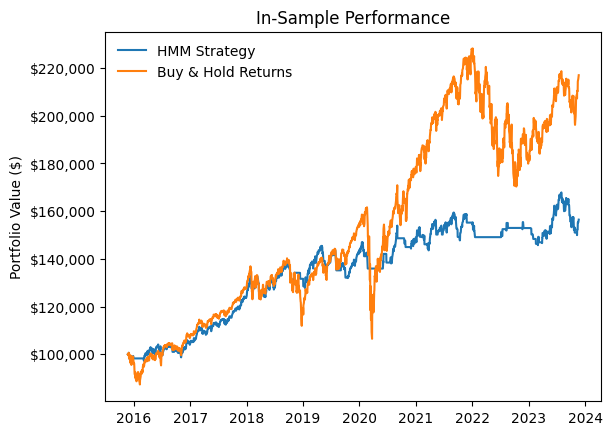

In [20]:
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'${x:,.0f}')
plt.plot(dates[: len(hmm_strategy_in_sample)], hmm_strategy_in_sample, label='HMM Strategy')
plt.plot(dates[: len(hmm_strategy_in_sample)], buy_hold_in_sample, label='Buy & Hold Returns')
plt.legend(loc='upper left', framealpha=0)
plt.title('In-Sample Performance')
plt.ylabel('Portfolio Value ($)')
plt.gca().yaxis.set_major_formatter(formatter)

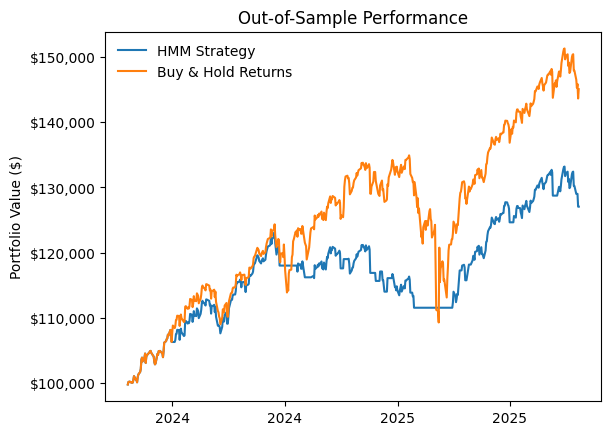

In [21]:
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.plot(dates[len(hmm_strategy_in_sample):], hmm_strategy_out_of_sample, label='HMM Strategy')
plt.plot(dates[len(hmm_strategy_in_sample):], buy_hold_out_of_sample, label='Buy & Hold Returns')
plt.legend(loc='upper left', framealpha=0)
plt.title('Out-of-Sample Performance')
plt.ylabel('Portfolio Value ($)')
plt.gca().yaxis.set_major_formatter(formatter)

In [ ]:
def calculate_metrics(log_returns, rf_rate=0.02):
    """
    Computes performance metrics from daily log returns.
    
    Parameters:
    log_returns : array-like (list, np.array, or pandas Series) Daily log returns of the strategy.

    rf_rate : float
        Annual risk-free rate (default = 0.02 for 2%).
        
    Returns:
    dict : performance metrics
    """
    
    log_returns = np.array(log_returns)
    log_returns = log_returns[~np.isnan(log_returns)]
    
    n_days = len(log_returns)
    n_years = n_days / 252  # trading years
    
    # ---- Metrics ----
    
    # 1. Cumulative Return (%)
    cumulative_return = (np.exp(log_returns.sum()) - 1) * 100
    
    # 2. Annualized Return (%)
    annualized_return = (np.exp(log_returns.mean() * 252) - 1) * 100
    
    # 3. Annualized Volatility (%)
    annualized_volatility = np.std(log_returns, ddof=1) * np.sqrt(252) * 100
    
    # 4. Sharpe Ratio (rf_rate assumed annualized)
    daily_rf = rf_rate / 252
    excess_returns = log_returns - daily_rf
    sharpe_ratio = (excess_returns.mean() / np.std(log_returns, ddof=1)) * np.sqrt(252)
    
    # 5. Maximum Drawdown (%)
    cumulative_wealth = np.exp(np.cumsum(log_returns))
    running_max = np.maximum.accumulate(cumulative_wealth)
    drawdown = (cumulative_wealth - running_max) / running_max
    max_drawdown = np.min(drawdown) * 100
    
    # 6. Win Rate (%)
    win_rate = (log_returns > 0).sum() / n_days * 100
    
    # 7. Average Win (%)
    wins = log_returns[log_returns > 0]
    avg_win = wins.mean() * 100 if len(wins) > 0 else 0
    
    # 8. Average Loss (%)
    losses = log_returns[log_returns < 0]
    avg_loss = losses.mean() * 100 if len(losses) > 0 else 0
    
    metrics = {
        "cumulative_return (%)": round(cumulative_return, 2),
        "annualized_return (%)": round(annualized_return, 2),
        "annualized_volatility (%)": round(annualized_volatility, 2),
        "sharpe_ratio": round(sharpe_ratio, 2),
        "max_drawdown (%)": round(max_drawdown, 2),
        "win_rate (%)": round(win_rate, 2),
        "avg_win (%)": round(avg_win*100, 2),
        "avg_loss (%)": round(avg_loss*100, 2)
    }
    
    return metrics


In [23]:

hmm_insamp_res = calculate_metrics(in_sample_returns)
hmm_oos_res = calculate_metrics(out_of_sample_returns)
buy_and_hold_insamp_res = calculate_metrics(train[1:])
buy_and_hold_oos_res = calculate_metrics(test[1:])

print("HMM Strategy In-Sample Performance Metrics:\n")
for key, value in hmm_insamp_res.items():
    print(f"{key}: {value}")

print("\nBuy and Hold In-Sample Performance Metrics:\n")
for key, value in buy_and_hold_insamp_res.items():
    print(f"{key}: {value}")

HMM Strategy In-Sample Performance Metrics:

cumulative_return (%): 56.44
annualized_return (%): 5.77
annualized_volatility (%): 8.71
sharpe_ratio: 0.41
max_drawdown (%): -10.66
win_rate (%): 34.13
avg_win (%): 48.17
avg_loss (%): -51.85

Buy and Hold In-Sample Performance Metrics:

cumulative_return (%): 117.02
annualized_return (%): 10.21
annualized_volatility (%): 18.63
sharpe_ratio: 0.41
max_drawdown (%): -34.1
win_rate (%): 54.31
avg_win (%): 73.64
avg_loss (%): -79.6


In [24]:
print("\nHMM Strategy Out-of-Sample Performance Metrics:\n")
for key, value in hmm_oos_res.items():
    print(f"{key}: {value}")

print("\nBuy and Hold Out-of-Sample Performance Metrics:\n")
for key, value in buy_and_hold_oos_res.items():
    print(f"{key}: {value}")


HMM Strategy Out-of-Sample Performance Metrics:

cumulative_return (%): 27.05
annualized_return (%): 12.74
annualized_volatility (%): 10.24
sharpe_ratio: 0.98
max_drawdown (%): -9.43
win_rate (%): 43.74
avg_win (%): 53.24
avg_loss (%): -58.6

Buy and Hold Out-of-Sample Performance Metrics:

cumulative_return (%): 45.39
annualized_return (%): 20.67
annualized_volatility (%): 16.26
sharpe_ratio: 1.03
max_drawdown (%): -19.0
win_rate (%): 58.37
avg_win (%): 63.4
avg_loss (%): -70.97


# Gradient Ascent

Recall the likelihood for our HMM model is given by:
\begin{align*}
\mathcal{L}(\lambda) 
= \mathbb{P}(O_{1:T} \mid \lambda)
= \sum_{j=1}^{N} \alpha_T(j)
\end{align*}
where $\lambda = (\pi, A, B)$ denotes the collection of model parameters. Similarly, taking the natural log,
\begin{align*}
\ell(\lambda) 
= \log \mathcal{L}(\lambda) 
= \log \left( \sum_{j=1}^N \alpha_T(j) \right)
\end{align*}
where we seek parameters that maximize $\ell(\lambda)$.

In principle, we could apply gradient ascent to this objective. Given a current parameter estimate $\lambda^{(k)}$, a generic gradient-ascent step takes the form
\begin{align*}
\lambda^{(k+1)} 
= \lambda^{(k)} + \eta \,\nabla_\lambda \,\ell\big(\lambda^{(k)}\big)
\end{align*}
where $\eta > 0$ is a learning rate and $\nabla_\lambda \ell(\lambda)$ denotes the gradient of the log-likelihood with respect to the HMM parameters. Using the forward–backward algorithm, these gradients can be expressed in terms of the expected sufficient statistics. For example, for the transition probabilities one can show that
\begin{align*}
\frac{\partial \,\ell(\lambda)}{\partial a_{ij}}
= \frac{1}{a_{ij}} \sum_{t=1}^{T-1} \xi_t(i,j) 
\end{align*}
where $\xi_t(i,j) = \mathbb{P}(Z_t = i, Z_{t+1} = j \mid O_{1:T}, \lambda)$ denotes the expected number of transitions from state $i$ to state $j$ at time $t$. Similar expressions can be derived for the initial distribution $\pi$ and the emission parameters.

In practice, however, directly applying gradient ascent is complicated by the constraints that each row of $A$ and the vector $\pi$ must lie on the probability simplex (i.e., entries are nonnegative and sum to one). One way to enforce these constraints is to reparameterize $A$ and $\pi$ using a softmax transformation and perform unconstrained gradient updates in the transformed space.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class HMMGaussian(nn.Module):
    def __init__(self, n_states=2, n_features=1):
        super().__init__()
        self.n_states = n_states
        self.n_features = n_features
        
        self.logits_pi = nn.Parameter(torch.randn(n_states))             
        self.logits_A  = nn.Parameter(torch.randn(n_states, n_states))   
        
        # Gaussian means and variances
        self.means = nn.Parameter(torch.randn(n_states, n_features))
        self.log_vars = nn.Parameter(torch.zeros(n_states, n_features))  
        
    def initialize(self, O):
        """Initialize parameters using GMM fit on observations."""
        O_np = O.numpy() if isinstance(O, torch.Tensor) else O
        if O_np.ndim == 1:
            O_np = O_np.reshape(-1, 1)
        
        pi_init, A_init, mu_init, sigma_init = init_hmm_gmm(O_np, self.n_states)
        
        with torch.no_grad():
            # Convert probabilities to logits (inverse of softmax)
            self.logits_pi.copy_(torch.log(torch.tensor(pi_init, dtype=torch.float32) + 1e-8))
            self.logits_A.copy_(torch.log(torch.tensor(A_init, dtype=torch.float32) + 1e-8))
            
            self.means.copy_(torch.tensor(mu_init, dtype=torch.float32))
            
            # Extract diagonal variances from full covariance matrices
            variances = np.array([np.diag(sigma_init[j]) for j in range(self.n_states)])
            self.log_vars.copy_(torch.log(torch.tensor(variances, dtype=torch.float32) + 1e-8))
        
        return self  

    def compute_emission(self, O):
        """
        Compute log p(O_t | Z=j) for each state j
        Returns: (T,N) log-probabilities
        """
        T = O.shape[0]
        O = O.unsqueeze(1)                      # (T,1,M)
        means = self.means.unsqueeze(0)         # (1,N,M)
        vars_ = torch.exp(self.log_vars)        # (N,M)
        
        # Gaussian log pdf
        log_probs = -0.5 * (((O - means)**2) / vars_).sum(dim=2)
        log_probs += -0.5 * (torch.log(2 * torch.pi * vars_).sum(dim=1))
        return log_probs                      

    def forward_algorithm(self, O):
        """
        Compute log-likelihood using log-sum-exp forward pass
        """
        T = O.shape[0]

        # Convert logits to probabilities
        log_pi = torch.log_softmax(self.logits_pi, dim=0)
        log_A  = torch.log_softmax(self.logits_A, dim=1)

        log_B = self.compute_emission(O)       

        # Forward pass in log-space
        log_alpha = torch.zeros(T, self.n_states)
        log_alpha[0] = log_pi + log_B[0]

        for t in range(1, T):
            # logsumexp over previous states
            inner = log_alpha[t-1].unsqueeze(1) + log_A  
            log_alpha[t] = log_B[t] + torch.logsumexp(inner, dim=0)

        # Total log-likelihood
        return torch.logsumexp(log_alpha[-1], dim=0)

    def negative_log_likelihood(self, O):
        return -self.forward_algorithm(O)




In [26]:
O = torch.tensor(train, dtype=torch.float32) 

model = HMMGaussian(n_states=2, n_features=O.shape[1]).initialize(O)
optimizer = optim.Adam(model.parameters(), lr=0.01)  

max_iters = 1000
patience = 100          
tol = 1e-6             
best_loss = float('inf')
stall_count = 0

for step in range(max_iters):
    optimizer.zero_grad()
    loss = model.negative_log_likelihood(O)
    loss.backward()
    optimizer.step()

    if loss.item() + tol < best_loss:
        best_loss = loss.item()
        stall_count = 0
    else:
        stall_count += 1

    if step % 100 == 0:
        print(f"Iter {step:04d} | Log-Likelihood = {-loss.item():.6f}")

    # Stop if loss has stalled
    if stall_count >= patience:
        print(f"\n Training stopped early at iter {step} (loss stalled)")
        break

print("\n Final Log-Likelihood:", -np.round(best_loss,3))


Iter 0000 | Log-Likelihood = 6413.344727
Iter 0100 | Log-Likelihood = 6490.015137
Iter 0200 | Log-Likelihood = 6559.910156
Iter 0300 | Log-Likelihood = 6567.745117
Iter 0400 | Log-Likelihood = 6568.076172
Iter 0500 | Log-Likelihood = 6568.211914

 Training stopped early at iter 519 (loss stalled)

 Final Log-Likelihood: 6568.379


In [27]:
print("\nEstimated parameters after PyTorch optimization:")
with torch.no_grad():
    pi_est = torch.softmax(model.logits_pi, dim=0)
    A_est  = torch.softmax(model.logits_A , dim=1)
    print("\nEstimated pi:\n", pi_est)
    print("\nEstimated A:\n", A_est)
    print("\nEstimated means:\n", model.means[:,0])
    print("\nEstimated variances:\n", torch.exp(model.log_vars))


Estimated parameters after PyTorch optimization:

Estimated pi:
 tensor([3.4134e-09, 1.0000e+00])

Estimated A:
 tensor([[0.9665, 0.0335],
        [0.0211, 0.9789]])

Estimated means:
 tensor([-0.0008,  0.0011], requires_grad=True)

Estimated variances:
 tensor([[3.0527e-04],
        [3.1089e-05]])


In [28]:
print("Estimated parameters after Baum-Welch:")
print("\nEstimated pi:\n", pi)
print("\nEstimated A:\n", np.round(A,4))
print("\nEstimated means:\n", np.round(means[:,0],4))
print("\nEstimated variances:\n", np.round([np.diag(covars[i]) for i in range(covars.shape[0])],4))

Estimated parameters after Baum-Welch:

Estimated pi:
 [0. 1.]

Estimated A:
 [[0.9667 0.0333]
 [0.0209 0.9791]]

Estimated means:
 [-0.0008  0.0011]

Estimated variances:
 [[0.0003]
 [0.    ]]
